## Granger Causality in Time Series Analysis

RUNNING BIVARIATE GRANGER CAUSALITY TEST (Sentiment -> Stock Price)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=902.0992, p=0.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=904.8163, p=0.0000  , df=1
likelihood ratio test: chi2=644.2161, p=0.0000  , df=1
parameter F test:         F=902.0992, p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=451.3024, p=0.0000  , df_denom=993, df_num=2
ssr based chi2 test:   chi2=907.1497, p=0.0000  , df=2
likelihood ratio test: chi2=645.2695, p=0.0000  , df=2
parameter F test:         F=451.3024, p=0.0000  , df_denom=993, df_num=2


c:\Users\Himanshu Saxena\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


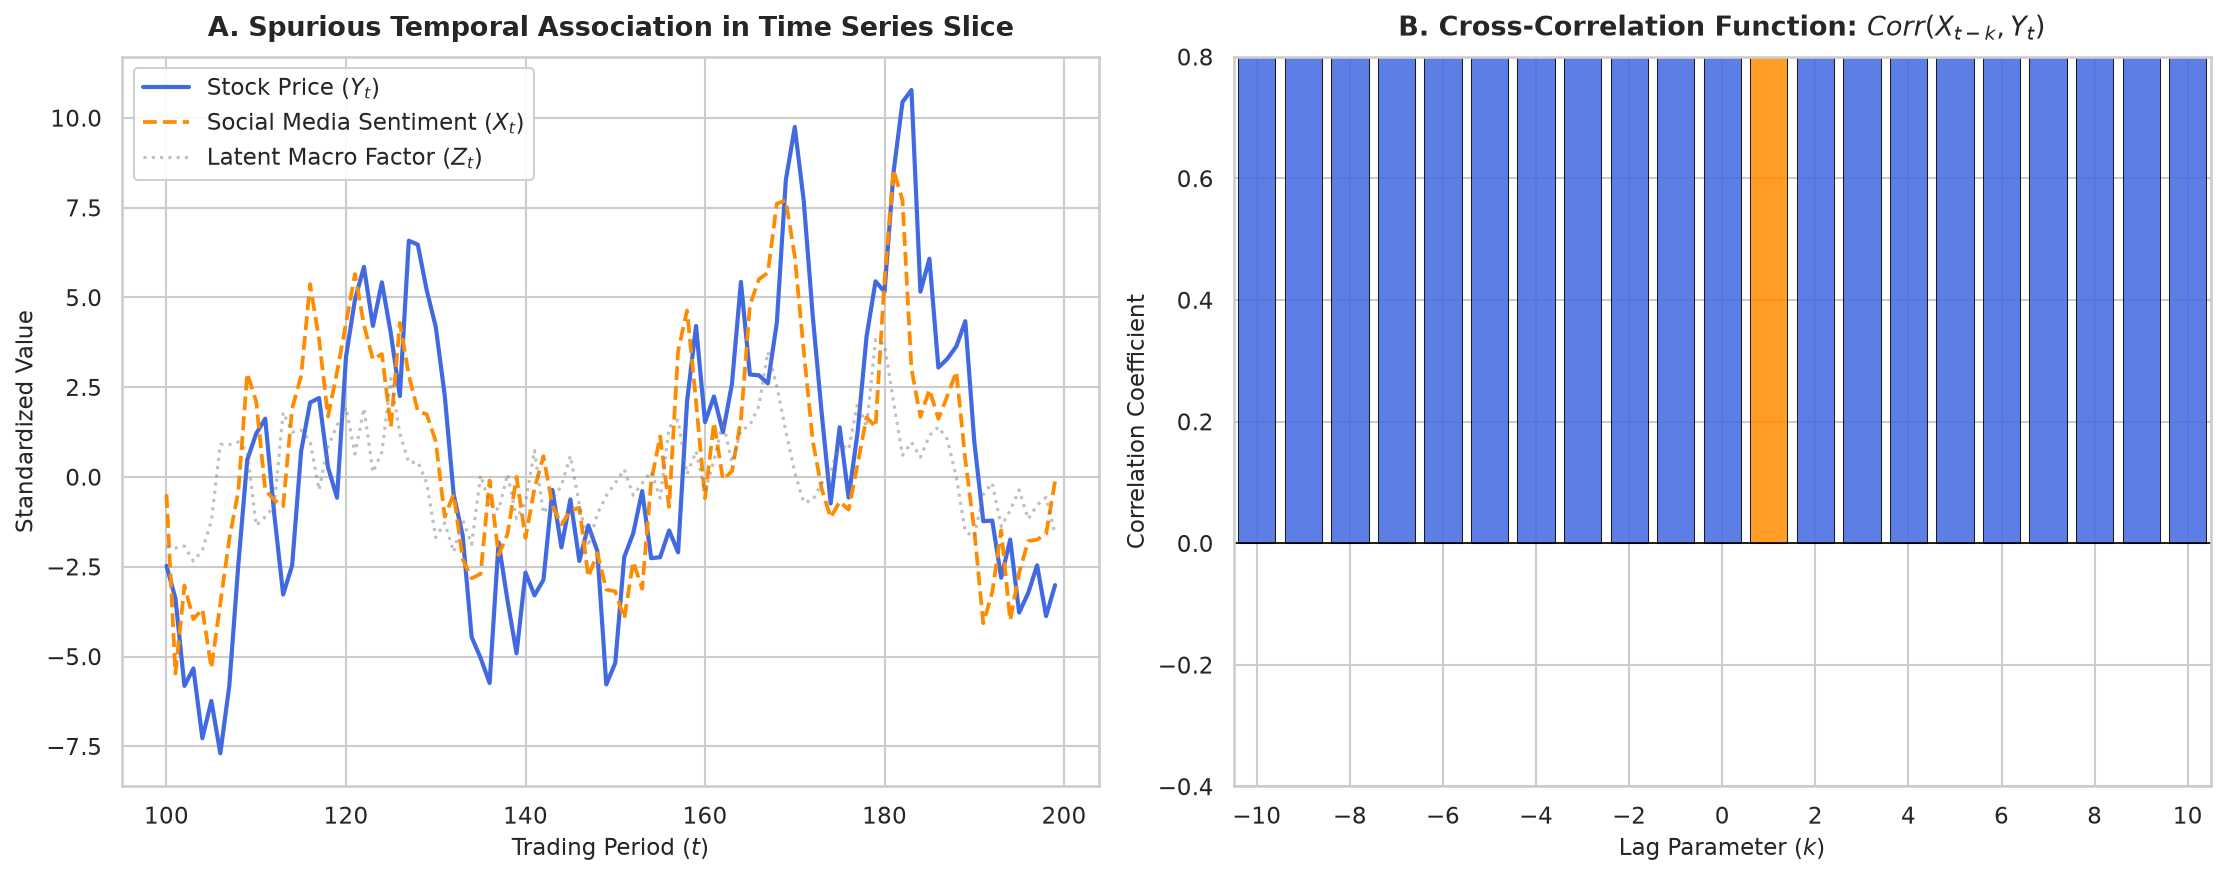

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests

# Set plotting style
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')
plt.rcParams['figure.dpi'] = 150


# 1. Simulate the Confounded Time Series System (T = 1000)

np.random.seed(42)
T = 1000

# Generate unobserved macroeconomic factor Z (modeled as an AR(1) process)
Z = np.zeros(T)
epsilon_Z = np.random.normal(0, 1, T)
for t in range(1, T):
    Z[t] = 0.8 * Z[t-1] + epsilon_Z[t]

# Generate Social Media Sentiment X (influenced by Z with a lag of 1)
X = np.zeros(T)
epsilon_X = np.random.normal(0, 1, T)
for t in range(1, T):
    X[t] = 0.5 * X[t-1] + 1.2 * Z[t-1] + epsilon_X[t]

# Generate Stock Price Y (influenced by Z with a lag of 2)
# Note: There is NO structural path from X -> Y
Y = np.zeros(T)
epsilon_Y = np.random.normal(0, 1, T)
for t in range(2, T):
    Y[t] = 0.6 * Y[t-1] + 1.5 * Z[t-2] + epsilon_Y[t]

# Create a clean DataFrame
df = pd.DataFrame({
    'Sentiment': X,
    'Stock_Price': Y,
    'Macro_Factor': Z
})


# 2. Run the Bivariate Granger Causality Test: X -> Y

print("="*65)
print("RUNNING BIVARIATE GRANGER CAUSALITY TEST (Sentiment -> Stock Price)")
print("="*65)
# grangercausalitytests expects [target_variable, predictor_variable]
gc_results = grangercausalitytests(df[['Stock_Price', 'Sentiment']], maxlag=2, verbose=True)



# 3. Compute Empirical Cross-Correlations

lags = np.arange(-10, 11)
cross_corr = []
for lag in lags:
    if lag < 0:
        # Correlation between X_{t-lag} and Y_t
        c = df['Sentiment'].iloc[-lag:].corr(df['Stock_Price'].iloc[:lag])
    elif lag > 0:
        # Correlation between X_t and Y_{t+lag}
        c = df['Sentiment'].iloc[:-lag].corr(df['Stock_Price'].iloc[lag:])
    else:
        c = df['Sentiment'].corr(df['Stock_Price'])
    cross_corr.append(c)


# 4. Publication-Quality Visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Time Series Visualization (Slice of 100 periods)
slice_range = slice(100, 200)
time_grid = np.arange(100, 200)

ax1.plot(time_grid, df['Stock_Price'].iloc[slice_range], label='Stock Price ($Y_t$)', color='royalblue', linewidth=2)
ax1.plot(time_grid, df['Sentiment'].iloc[slice_range], label='Social Media Sentiment ($X_t$)', color='darkorange', linewidth=1.8, linestyle='--')
ax1.plot(time_grid, df['Macro_Factor'].iloc[slice_range], label='Latent Macro Factor ($Z_t$)', color='gray', alpha=0.5, linewidth=1.5, linestyle=':')

ax1.set_title("A. Spurious Temporal Association in Time Series Slice", fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel("Trading Period ($t$)", fontsize=11)
ax1.set_ylabel("Standardized Value", fontsize=11)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)

# Panel B: Cross-Correlation Function (CCF)
colors = ['darkorange' if lag == 1 else 'royalblue' for lag in lags]
ax2.bar(lags, cross_corr, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.8)

# Highlight key correlations
max_corr_idx = np.argmax(cross_corr)
ax2.annotate(f"Spurious Peak\n(r = {cross_corr[max_corr_idx]:.2f} at lag 1)", 
             xy=(lags[max_corr_idx], cross_corr[max_corr_idx]),
             xytext=(lags[max_corr_idx]+2, cross_corr[max_corr_idx]-0.15),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))

ax2.set_title("B. Cross-Correlation Function: $Corr(X_{t-k}, Y_t)$", fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel("Lag Parameter ($k$)", fontsize=11)
ax2.set_ylabel("Correlation Coefficient", fontsize=11)
ax2.set_xlim(-10.5, 10.5)
ax2.set_ylim(-0.4, 0.8)
ax2.set_xticks(np.arange(-10, 11, 2))

plt.tight_layout()
plt.show()
